In [64]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Import สำเร็จ")

✅ Import สำเร็จ


In [65]:
# หุ้น SET100 ตัวอย่าง 30 ตัวก่อน
# yFinance ใช้ suffix .BK สำหรับหุ้นไทย
tickers = [
    "AOT.BK",   # ท่าอากาศยาน
    "PTT.BK",   # ปตท
    "CPALL.BK", # CP ALL
    "SCB.BK",   # ไทยพาณิชย์
    "KBANK.BK", # กสิกรไทย
    "BBL.BK",   # กรุงเทพ
    "KTB.BK",   # กรุงไทย
    "SCC.BK",   # ปูนซิเมนต์ไทย
    "GULF.BK",  # กัลฟ์
    "ADVANC.BK",# AIS
    "INTUCH.BK",# อินทัช
    "TRUE.BK",  # ทรู
    "BH.BK",    # โรงพยาบาลบำรุงราษฎร์
    "BDMS.BK",  # กรุงเทพดุสิตเวชการ
    "CPN.BK",   # เซ็นทรัลพัฒนา
    "LH.BK",    # แลนด์แอนด์เฮ้าส์
    "MINT.BK",  # ไมเนอร์
    "TOP.BK",   # ไทยออยล์
    "IRPC.BK",  # IRPC
    "PTTEP.BK", # ปตท.สผ
]

print(f"✅ จำนวนหุ้นที่จะ Screen: {len(tickers)} ตัว")

✅ จำนวนหุ้นที่จะ Screen: 20 ตัว


In [66]:
def get_fundamentals(ticker):
    try:
        stock = yf.Ticker(ticker)
        info  = stock.info

        # ฟังก์ชันช่วย convert ให้ปลอดภัย
        def pct(key):
            val = info.get(key, np.nan)
            if val is None: return np.nan
            # ถ้าค่าน้อยกว่า 1 แสดงว่าเป็น decimal → คูณ 100
            # ถ้ามากกว่า 1 แสดงว่าเป็น % แล้ว → ใช้เลย
            if abs(val) <= 1:
                return round(val * 100, 2)
            return round(val, 2)

        data = {
            'Ticker'       : ticker.replace('.BK', ''),
            'Name'         : info.get('shortName', 'N/A'),
            'Sector'       : info.get('sector', 'N/A'),
            'Price'        : info.get('currentPrice', np.nan),
            'Market_Cap_B' : round(info.get('marketCap', 0) / 1e9, 2),

            # Valuation
            'PE'           : info.get('trailingPE', np.nan),
            'PBV'          : info.get('priceToBook', np.nan),
            'PS'           : info.get('priceToSalesTrailing12Months', np.nan),
            'EV_EBITDA'    : info.get('enterpriseToEbitda', np.nan),

            # Profitability
            'ROE'          : pct('returnOnEquity'),
            'ROA'          : pct('returnOnAssets'),
            'Net_Margin'   : pct('profitMargins'),
            'Gross_Margin' : pct('grossMargins'),

            # Health
            'DE_Ratio'     : info.get('debtToEquity', np.nan),
            'Current_Ratio': info.get('currentRatio', np.nan),

            # Dividend
            'Div_Yield'    : pct('dividendYield'),

            # Volume
            'Avg_Volume_M' : round(info.get('averageVolume', 0) / 1e6, 2),
        }
        return data

    except Exception as e:
        print(f"❌ {ticker}: {e}")
        return None

# ดึงข้อมูลใหม่
print("กำลังดึงข้อมูลใหม่...")
results = []
for ticker in tickers:
    data = get_fundamentals(ticker)
    if data:
        results.append(data)
        print(f"  ✅ {ticker}")

df = pd.DataFrame(results)
print(f"\n✅ เสร็จแล้ว {len(df)} ตัว")

กำลังดึงข้อมูลใหม่...
  ✅ AOT.BK
  ✅ PTT.BK
  ✅ CPALL.BK
  ✅ SCB.BK
  ✅ KBANK.BK
  ✅ BBL.BK
  ✅ KTB.BK
  ✅ SCC.BK
  ✅ GULF.BK
  ✅ ADVANC.BK
  ✅ INTUCH.BK
  ✅ TRUE.BK
  ✅ BH.BK
  ✅ BDMS.BK
  ✅ CPN.BK
  ✅ LH.BK
  ✅ MINT.BK
  ✅ TOP.BK
  ✅ IRPC.BK
  ✅ PTTEP.BK

✅ เสร็จแล้ว 20 ตัว


In [67]:
def screen_stocks(df,
                  max_pe=25,        # ไทยมี PE สูงกว่า US
                  max_pbv=4,
                  min_roe=8,        # ลดลงนิดนึง
                  min_net_margin=3, # ค้าปลีกและธนาคาร Margin ต่ำ
                  max_de=150,       # ธนาคารมี DE สูงมากเป็นปกติ
                  min_div_yield=1):

    screened = df.copy()

    # ใช้ dropna=False เพื่อไม่กรอง NaN ออก
    if max_pe:
        screened = screened[
            (screened['PE'] <= max_pe) | (screened['PE'].isna())
        ]
        screened = screened[screened['PE'].notna()]

    if max_pbv:
        screened = screened[
            (screened['PBV'] <= max_pbv) & (screened['PBV'].notna())
        ]

    if min_roe:
        screened = screened[
            (screened['ROE'] >= min_roe) & (screened['ROE'].notna())
        ]

    if min_net_margin:
        screened = screened[
            (screened['Net_Margin'] >= min_net_margin) & 
            (screened['Net_Margin'].notna())
        ]

    if max_de:
        # ถ้า DE เป็น NaN ให้ผ่านได้ (กรณีธนาคาร)
        screened = screened[
            (screened['DE_Ratio'] <= max_de) | 
            (screened['DE_Ratio'].isna())
        ]

    if min_div_yield:
        screened = screened[
            (screened['Div_Yield'] >= min_div_yield) & 
            (screened['Div_Yield'].notna())
        ]

    return screened.sort_values('ROE', ascending=False)

# รัน Screen ใหม่
result = screen_stocks(df)

print(f"✅ หุ้นที่ผ่าน Filter: {len(result)} ตัว\n")
cols = ['Ticker','Name','PE','PBV','ROE','Net_Margin','DE_Ratio','Div_Yield']
print(result[cols].to_string(index=False))

✅ หุ้นที่ผ่าน Filter: 8 ตัว

Ticker                       Name        PE      PBV   ROE  Net_Margin  DE_Ratio  Div_Yield
   CPN        CPN_CENTRAL PATTANA 15.059525 2.583425 16.74       34.81    97.834       3.79
  BDMS BDMS_BANGKOK DUSIT MEDICAL 18.900000 2.836560 15.30       14.00    15.896       4.23
 PTTEP  PTTEP_PTT EXPLORATION AND 10.144927 1.133547 11.36       21.38    24.400       5.68
   KTB        KTB_KRUNG THAI BANK 10.000000 1.038719 11.02       37.14       NaN      10.48
   SCB                  SCB_SCB X 10.319149 0.989103  9.68       36.50       NaN       7.75
 KBANK         KBANK_KASIKORNBANK  9.181202 0.772590  8.45       32.08       NaN       6.33
   BBL           BBL_BANGKOK BANK  6.887967 0.552110  8.19       32.32       NaN       9.94
   TOP               TOP_THAI OIL  7.006125 0.594341  8.15        4.41    69.274       4.37


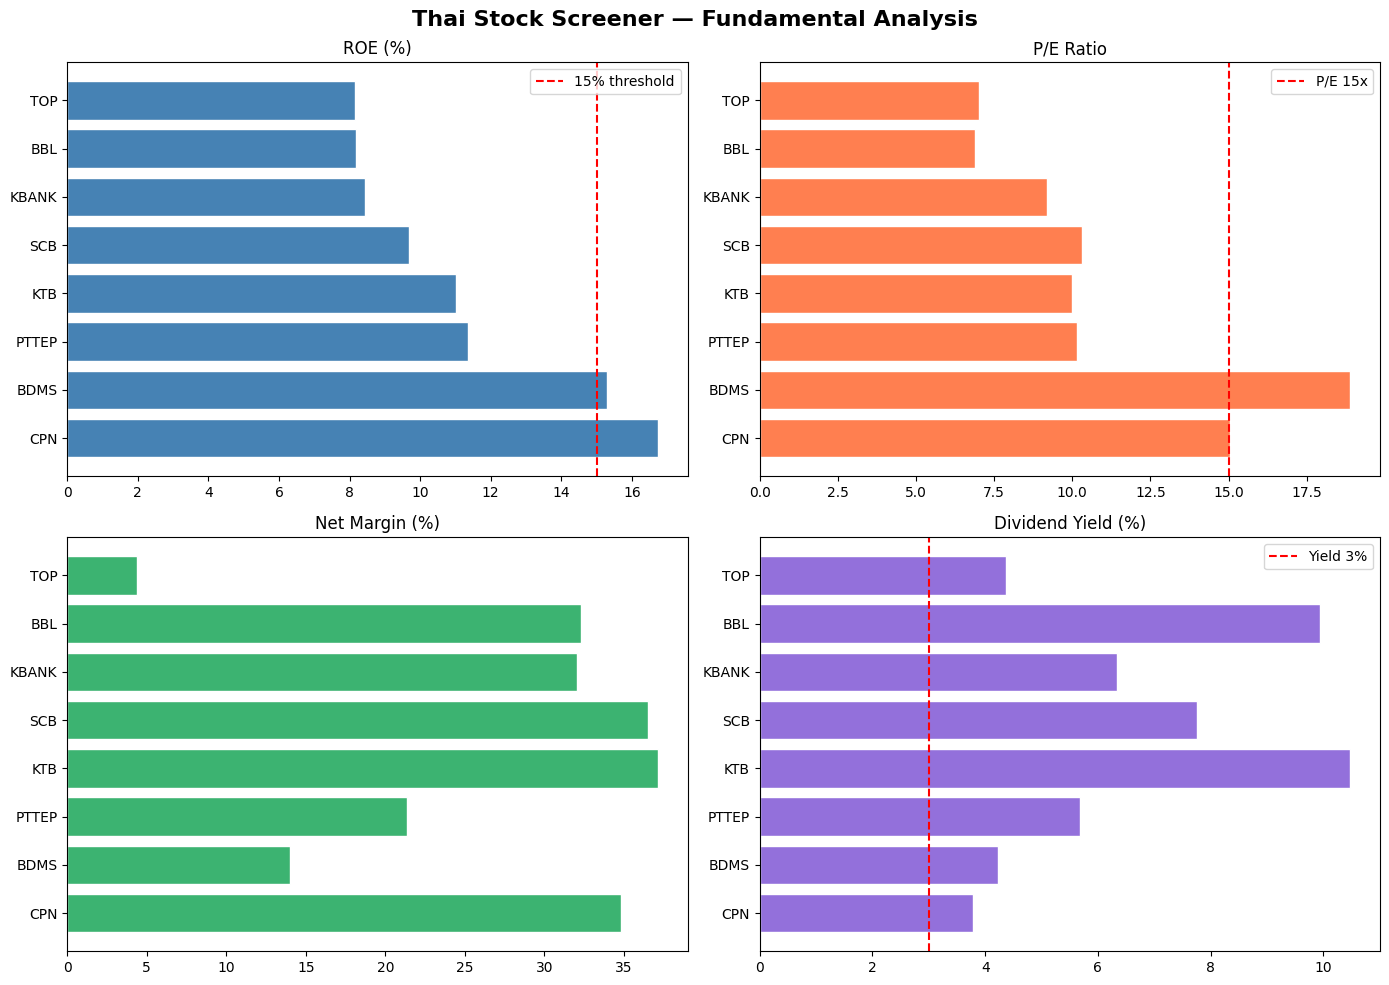

✅ บันทึกกราฟแล้ว


In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Thai Stock Screener — Fundamental Analysis',
             fontsize=16, fontweight='bold')

# 1) ROE Comparison
axes[0,0].barh(result['Ticker'], result['ROE'],
               color='steelblue', edgecolor='white')
axes[0,0].axvline(x=15, color='red', linestyle='--', label='15% threshold')
axes[0,0].set_title('ROE (%)')
axes[0,0].legend()

# 2) P/E Comparison
axes[0,1].barh(result['Ticker'], result['PE'],
               color='coral', edgecolor='white')
axes[0,1].axvline(x=15, color='red', linestyle='--', label='P/E 15x')
axes[0,1].set_title('P/E Ratio')
axes[0,1].legend()

# 3) Net Margin
axes[1,0].barh(result['Ticker'], result['Net_Margin'],
               color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Net Margin (%)')

# 4) Dividend Yield
axes[1,1].barh(result['Ticker'], result['Div_Yield'],
               color='mediumpurple', edgecolor='white')
axes[1,1].axvline(x=3, color='red', linestyle='--', label='Yield 3%')
axes[1,1].set_title('Dividend Yield (%)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('thai_stock_screener.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึกกราฟแล้ว")

In [69]:
# ดูข้อมูลจริงที่ดึงมาได้
cols = ['Ticker', 'PE', 'PBV', 'ROE', 'Net_Margin', 'DE_Ratio', 'Div_Yield']
print(df[cols].to_string(index=False))

Ticker        PE       PBV   ROE  Net_Margin  DE_Ratio  Div_Yield
   AOT 39.634144  5.139152 13.23       26.47    32.854       1.66
   PTT 10.793651  0.854185  7.12        3.39    59.656       6.18
 CPALL 14.677420  3.163017  9.79        2.76   133.418       3.63
   SCB 10.319149  0.989103  9.68       36.50       NaN       7.75
 KBANK  9.181202  0.772590  8.45       32.08       NaN       6.33
   BBL  6.887967  0.552110  8.19       32.32       NaN       9.94
   KTB 10.000000  1.038719 11.02       37.14       NaN      10.48
   SCC 15.771526  0.657383  2.59        2.83    83.838       2.70
  GULF 33.187134  2.525815 35.04       69.24    99.499       1.85
ADVANC 23.587833 10.545303 46.81       21.16   179.229       4.43
INTUCH       NaN       NaN   NaN         NaN       NaN        NaN
  TRUE 52.222220  6.453090 12.20        4.72   577.067       2.20
    BH 18.663593  4.172892 25.65       29.52     0.342       3.09
  BDMS 18.900000  2.836560 15.30       14.00    15.896       4.23
   CPN 15.

In [70]:
# เช็คว่าค่าจริงๆ เป็น NaN เท่าไหร่
cols = ['Ticker','PE','PBV','ROE','Net_Margin','DE_Ratio','Div_Yield']
print(df[cols].to_string(index=False))
print("\n--- Missing Values ---")
print(df[cols].isnull().sum())

Ticker        PE       PBV   ROE  Net_Margin  DE_Ratio  Div_Yield
   AOT 39.634144  5.139152 13.23       26.47    32.854       1.66
   PTT 10.793651  0.854185  7.12        3.39    59.656       6.18
 CPALL 14.677420  3.163017  9.79        2.76   133.418       3.63
   SCB 10.319149  0.989103  9.68       36.50       NaN       7.75
 KBANK  9.181202  0.772590  8.45       32.08       NaN       6.33
   BBL  6.887967  0.552110  8.19       32.32       NaN       9.94
   KTB 10.000000  1.038719 11.02       37.14       NaN      10.48
   SCC 15.771526  0.657383  2.59        2.83    83.838       2.70
  GULF 33.187134  2.525815 35.04       69.24    99.499       1.85
ADVANC 23.587833 10.545303 46.81       21.16   179.229       4.43
INTUCH       NaN       NaN   NaN         NaN       NaN        NaN
  TRUE 52.222220  6.453090 12.20        4.72   577.067       2.20
    BH 18.663593  4.172892 25.65       29.52     0.342       3.09
  BDMS 18.900000  2.836560 15.30       14.00    15.896       4.23
   CPN 15.

In [71]:
for _, row in df.iterrows():
    print(f"{row['Ticker']:10} PE={row['PE']:6.1f}  ROE={row['ROE']:6.1f}  Margin={row['Net_Margin']:6.1f}  DE={row['DE_Ratio']:6.2f}  Yield={row['Div_Yield']:5.2f}")

AOT        PE=  39.6  ROE=  13.2  Margin=  26.5  DE= 32.85  Yield= 1.66
PTT        PE=  10.8  ROE=   7.1  Margin=   3.4  DE= 59.66  Yield= 6.18
CPALL      PE=  14.7  ROE=   9.8  Margin=   2.8  DE=133.42  Yield= 3.63
SCB        PE=  10.3  ROE=   9.7  Margin=  36.5  DE=   nan  Yield= 7.75
KBANK      PE=   9.2  ROE=   8.4  Margin=  32.1  DE=   nan  Yield= 6.33
BBL        PE=   6.9  ROE=   8.2  Margin=  32.3  DE=   nan  Yield= 9.94
KTB        PE=  10.0  ROE=  11.0  Margin=  37.1  DE=   nan  Yield=10.48
SCC        PE=  15.8  ROE=   2.6  Margin=   2.8  DE= 83.84  Yield= 2.70
GULF       PE=  33.2  ROE=  35.0  Margin=  69.2  DE= 99.50  Yield= 1.85
ADVANC     PE=  23.6  ROE=  46.8  Margin=  21.2  DE=179.23  Yield= 4.43
INTUCH     PE=   nan  ROE=   nan  Margin=   nan  DE=   nan  Yield=  nan
TRUE       PE=  52.2  ROE=  12.2  Margin=   4.7  DE=577.07  Yield= 2.20
BH         PE=  18.7  ROE=  25.6  Margin=  29.5  DE=  0.34  Yield= 3.09
BDMS       PE=  18.9  ROE=  15.3  Margin=  14.0  DE= 15.90  Yiel

In [72]:
df.to_csv('all_stocks_data.csv', index=False)
result.to_csv('screened_stocks.csv', index=False)
print("✅ Export CSV สำเร็จ")
print(f"   - all_stocks_data.csv  ({len(df)} ตัว)")
print(f"   - screened_stocks.csv  ({len(result)} ตัว)")

✅ Export CSV สำเร็จ
   - all_stocks_data.csv  (20 ตัว)
   - screened_stocks.csv  (8 ตัว)


In [73]:
def score_stocks(df):
    """
    ให้คะแนนแต่ละหุ้น 0-100
    แบ่งเป็น 5 หมวด หมวดละ 20 คะแนน
    """
    scored = df.copy()

    def normalize(series, higher_is_better=True):
        """แปลงค่าให้อยู่ในช่วง 0-1"""
        s = series.copy()
        s_min = s.min()
        s_max = s.max()
        if s_max == s_min:
            return pd.Series([0.5] * len(s), index=s.index)
        normalized = (s - s_min) / (s_max - s_min)
        if not higher_is_better:
            normalized = 1 - normalized
        return normalized

    # หมวด 1: Valuation (20 คะแนน) — ยิ่งถูกยิ่งดี
    pe_score  = normalize(scored['PE'],  higher_is_better=False).fillna(0)
    pbv_score = normalize(scored['PBV'], higher_is_better=False).fillna(0)
    val_score = (pe_score + pbv_score) / 2 * 20

    # หมวด 2: Profitability (20 คะแนน) — ยิ่งสูงยิ่งดี
    roe_score    = normalize(scored['ROE'],        higher_is_better=True).fillna(0)
    margin_score = normalize(scored['Net_Margin'], higher_is_better=True).fillna(0)
    profit_score = (roe_score + margin_score) / 2 * 20

    # หมวด 3: Financial Health (20 คะแนน)
    de_score  = normalize(scored['DE_Ratio'],     higher_is_better=False).fillna(0.5)
    cur_score = normalize(scored['Current_Ratio'],higher_is_better=True).fillna(0.5)
    health_score = (de_score + cur_score) / 2 * 20

    # หมวด 4: Dividend (20 คะแนน)
    div_score = normalize(scored['Div_Yield'], higher_is_better=True).fillna(0) * 20

    # หมวด 5: Efficiency (20 คะแนน)
    roa_score = normalize(scored['ROA'], higher_is_better=True).fillna(0) * 20

    # รวมคะแนน
    scored['Score_Valuation']    = val_score.round(1)
    scored['Score_Profit']       = profit_score.round(1)
    scored['Score_Health']       = health_score.round(1)
    scored['Score_Dividend']     = div_score.round(1)
    scored['Score_Efficiency']   = roa_score.round(1)
    scored['Total_Score']        = (
        val_score + profit_score + health_score +
        div_score + roa_score
    ).round(1)

    # Grade
    def grade(score):
        if score >= 80: return 'A'
        if score >= 65: return 'B'
        if score >= 50: return 'C'
        if score >= 35: return 'D'
        return 'F'

    scored['Grade'] = scored['Total_Score'].apply(grade)

    return scored.sort_values('Total_Score', ascending=False)

# รัน Scoring บนหุ้นที่ผ่าน Filter
result_scored = score_stocks(result)

# แสดงผล
print("=" * 65)
print(f"{'Ticker':<8} {'Name':<25} {'Score':>6} {'Grade':>5}")
print("=" * 65)
for _, row in result_scored.iterrows():
    bar = '█' * int(row['Total_Score'] / 5)
    print(f"{row['Ticker']:<8} {str(row['Name'])[:24]:<25} "
          f"{row['Total_Score']:>5.1f}  {row['Grade']:>3}  {bar}")
print("=" * 65)

Ticker   Name                       Score Grade
PTTEP    PTTEP_PTT EXPLORATION AN   62.7    C  ████████████
KTB      KTB_KRUNG THAI BANK        59.6    C  ███████████
BBL      BBL_BANGKOK BANK           57.0    C  ███████████
SCB      SCB_SCB X                  49.6    D  █████████
BDMS     BDMS_BANGKOK DUSIT MEDIC   45.9    D  █████████
KBANK    KBANK_KASIKORNBANK         44.2    D  ████████
TOP      TOP_THAI OIL               36.4    D  ███████
CPN      CPN_CENTRAL PATTANA        35.6    D  ███████


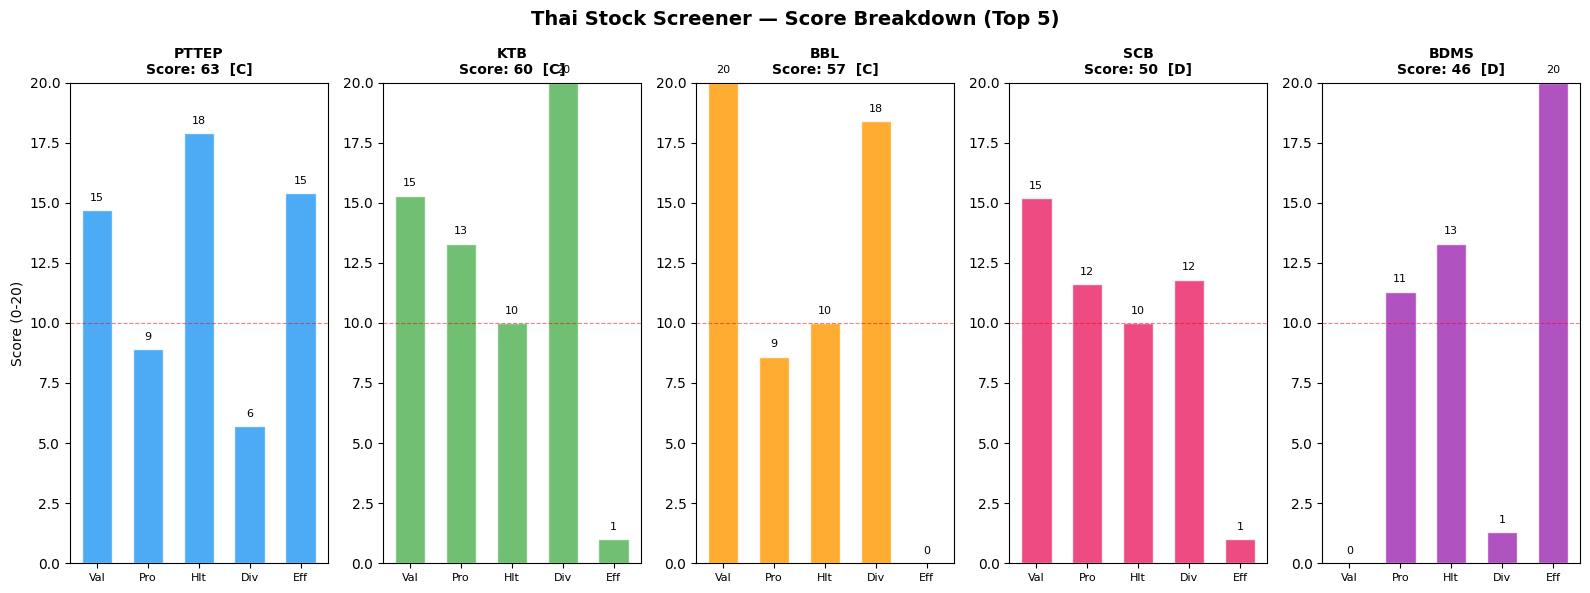

✅ บันทึกกราฟ Score แล้ว


In [74]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec

categories = ['Valuation','Profit','Health','Dividend','Efficiency']
score_cols  = ['Score_Valuation','Score_Profit',
               'Score_Health','Score_Dividend','Score_Efficiency']

# เลือก Top 5 มา Plot
top5 = result_scored.head(5)

fig = plt.figure(figsize=(16, 6))
fig.suptitle('Thai Stock Screener — Score Breakdown (Top 5)',
             fontsize=14, fontweight='bold')

colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

for idx, (_, row) in enumerate(top5.iterrows()):
    ax = fig.add_subplot(1, 5, idx+1)

    scores   = [row[c] for c in score_cols]
    x        = range(len(categories))
    bars     = ax.bar(x, scores, color=colors[idx],
                      alpha=0.8, edgecolor='white', width=0.6)
    ax.set_ylim(0, 20)
    ax.set_xticks(x)
    ax.set_xticklabels(['Val','Pro','Hlt','Div','Eff'],
                       fontsize=8)
    ax.set_title(f"{row['Ticker']}\n"
                 f"Score: {row['Total_Score']:.0f}  [{row['Grade']}]",
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Score (0-20)' if idx==0 else '')
    ax.axhline(y=10, color='red', linestyle='--',
               alpha=0.5, linewidth=0.8)

    # แสดงตัวเลขบน Bar
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{score:.0f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('thai_stock_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึกกราฟ Score แล้ว")

In [75]:
# Export พร้อม Score
final_cols = [
    'Ticker','Name','Sector','Price',
    'PE','PBV','ROE','Net_Margin','Div_Yield',
    'Total_Score','Grade',
    'Score_Valuation','Score_Profit',
    'Score_Health','Score_Dividend','Score_Efficiency'
]
result_scored[final_cols].to_csv('thai_stock_report.csv', index=False)
print("✅ Export thai_stock_report.csv สำเร็จ")
print(f"   {len(result_scored)} หุ้นที่ผ่าน Filter พร้อม Score")

✅ Export thai_stock_report.csv สำเร็จ
   8 หุ้นที่ผ่าน Filter พร้อม Score


In [76]:
readme = """# 🇹🇭 Thai Stock Screener

A Python-based fundamental analysis tool for screening
Thai SET stocks using key financial metrics.

## Features
- Screens SET stocks by Valuation, Profitability,
  Financial Health, and Dividend
- Scores each stock 0–100 across 5 dimensions
- Exports results to CSV
- Visualizes results with bar charts

## Metrics Used
| Category | Metrics |
|---|---|
| Valuation | P/E, P/BV |
| Profitability | ROE, Net Margin, ROA |
| Health | D/E Ratio, Current Ratio |
| Dividend | Dividend Yield |

## How to Run
```bash
pip install yfinance pandas numpy matplotlib seaborn
jupyter notebook thai_stock_screener.ipynb
```

## Sample Output
- `all_stocks_data.csv` — Raw data ทุกตัว
- `screened_stocks.csv` — หุ้นที่ผ่าน Filter
- `thai_stock_report.csv` — Report พร้อม Score
- `thai_stock_screener.png` — Fundamental Chart
- `thai_stock_scores.png` — Score Breakdown Chart

## Default Filter Criteria
- P/E ≤ 25
- P/BV ≤ 4
- ROE ≥ 8%
- Net Margin ≥ 3%
- Dividend Yield ≥ 1%

## Tech Stack
Python · Pandas · NumPy · yFinance · Matplotlib

## Disclaimer
For educational purposes only.
Not financial advice.
"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("✅ สร้าง README.md สำเร็จ")
print("\nไฟล์ทั้งหมดที่พร้อม Upload GitHub:")
print("  📓 thai_stock_screener.ipynb")
print("  📄 README.md")
print("  📊 thai_stock_screener.png")
print("  📊 thai_stock_scores.png")
print("  📋 thai_stock_report.csv")

✅ สร้าง README.md สำเร็จ

ไฟล์ทั้งหมดที่พร้อม Upload GitHub:
  📓 thai_stock_screener.ipynb
  📄 README.md
  📊 thai_stock_screener.png
  📊 thai_stock_scores.png
  📋 thai_stock_report.csv
